<a href="https://colab.research.google.com/github/gtzan/mir_book/blob/master/monophonic_pitch_estimation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Monophonic pitch estimation

### George Tzanetakis, University of Victoria

In this notebook we will explore different ways of extracting pitch from monophonic audio
signals. One synthetic melody example as well as an actual audio recording will be used
to illustrate the different approaches.


In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as signal
from scipy.interpolate import interp1d

import IPython.display as ipd

First let's create a synthetic simple melody using a sinusoid generation function.

In [ ]:
srate = 22050.0

# generate a discrete time sinusoid signal with a specified amplitude, frequency, duration, and phase
def sinusoid(freq=440.0, dur=1.0, srate=44100.0, amp=1.0, phase = 0.0):
    t = np.linspace(0,dur,int(srate*dur))
    data = amp * np.sin(2*np.pi*freq *t+phase)
    return data

# frequencies of three notes (C, D, E)
c_freq = 523.0
d_freq = 587.0
e_freq = 659.0

# generate sine signals corresponding to each note
c_data = sinusoid(c_freq, 0.5, srate)
d_data = sinusoid(d_freq, 0.5, srate)
e_data = sinusoid(e_freq, 0.5, srate)

# form a simple melody by concateneting the signal arrays for each note
melody1 = np.hstack([c_data, d_data, e_data, c_data, c_data, d_data, e_data, c_data])
ipd.Audio(melody1,rate=srate)

Let's also load an audio recording

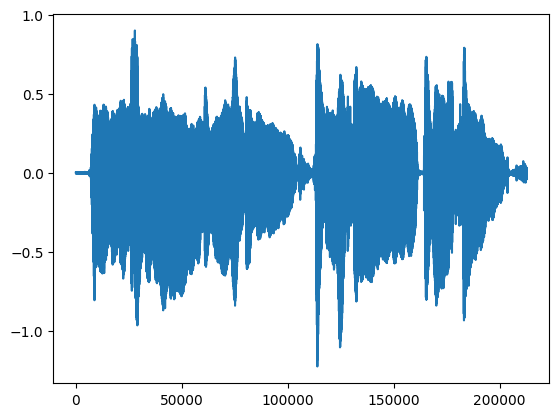

In [ ]:
import scipy.io.wavfile as wav
srate, audio_signal = wav.read("amazing_grace_female.wav")
# scale to -1.0/1.0
melody2 = audio_signal.astype(np.float32) / 32767.0
# make max be 0.9
melody2 = (0.9 / max(melody2)) * melody2

plt.figure()
plt.plot(melody2)
ipd.Audio(melody2,rate=srate)


We will be doing the processing in short chunks of the audio signal. This chunking process is common
in many digital signal processing algorithms and is characterized by two numbers: the hop size in samples which is the number of samples we advance the start of the chunk in each iteration, and the window size which is the number of samples each chunk (window) will contain. First let's look at a particular chunk (typically called
a window or a frame) for each input signal (the synthetic sinusoidal melody and the audio recording of Amazing Grace).  

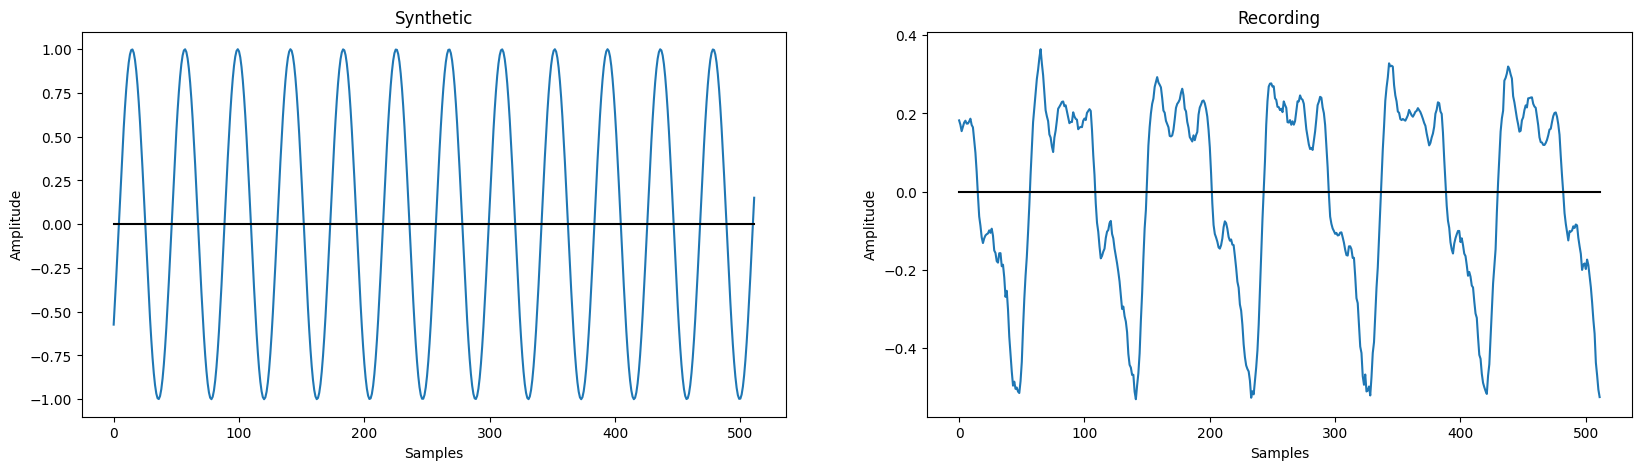

In [ ]:
hopSize = 256
winSize = 512

# let's plot the 40th window
o = 40 * hopSize
frame1 = melody1[o:o+winSize]
frame2 = melody2[o:o+winSize ]

plt.figure(figsize=(20,5))
plt.subplot(121)
plt.title('Synthetic')
plt.plot(frame1)
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.plot(np.zeros(len(frame1)), color='black')

plt.subplot(122)
plt.title('Recording')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.plot(frame2)
plt.plot(np.zeros(len(frame2)), color='black')

Let's look at a plot visualizing the short-time processing where the signal is processed in
overlapping chunks of size window size and advancing by hop size.

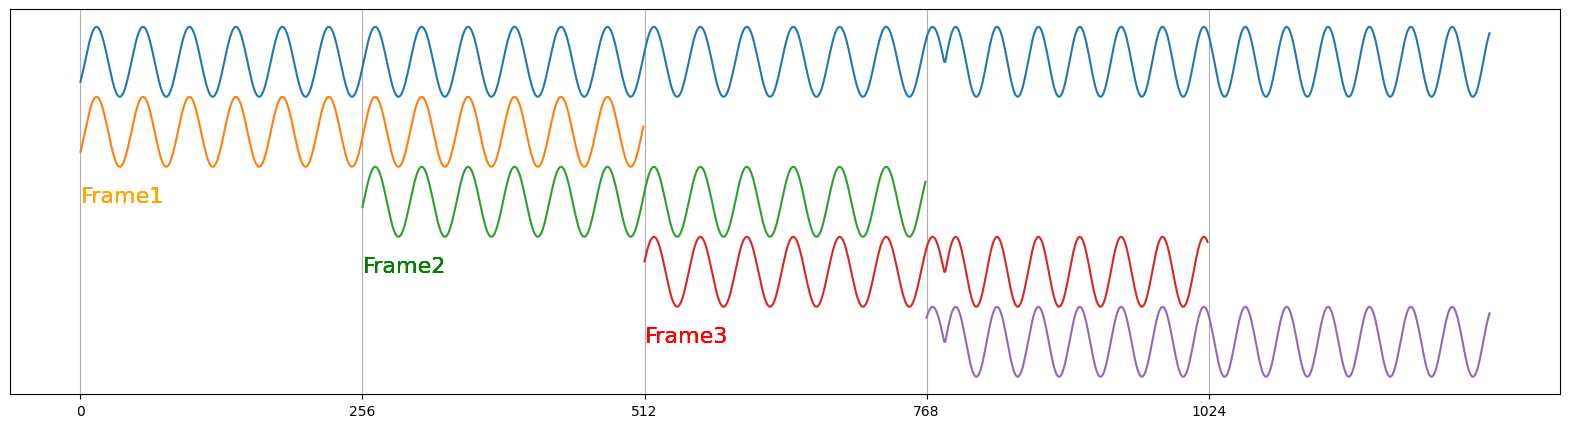

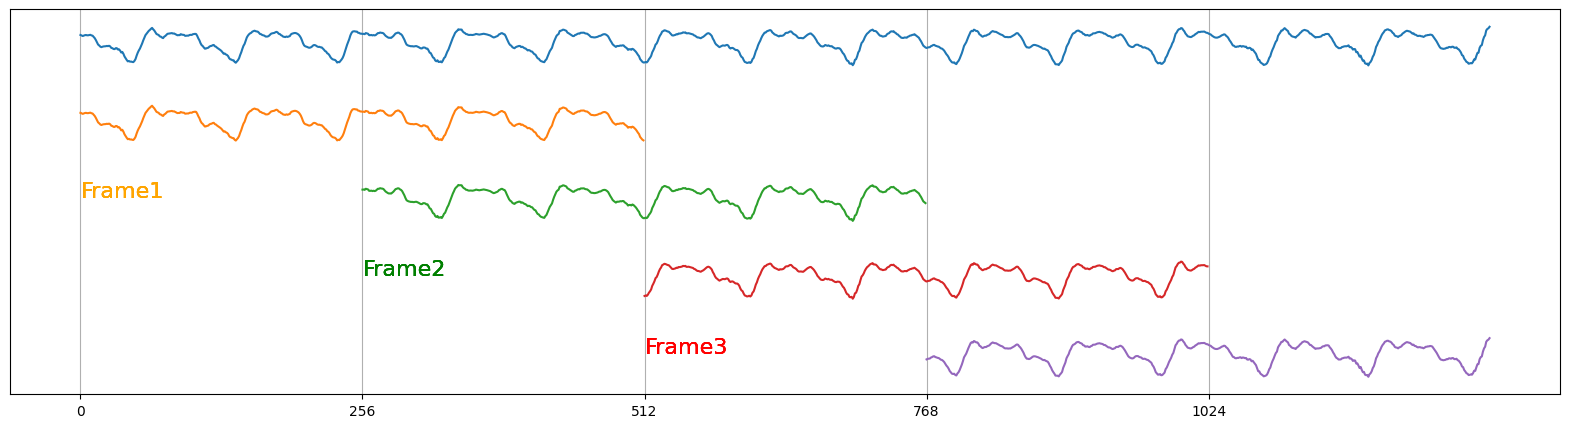

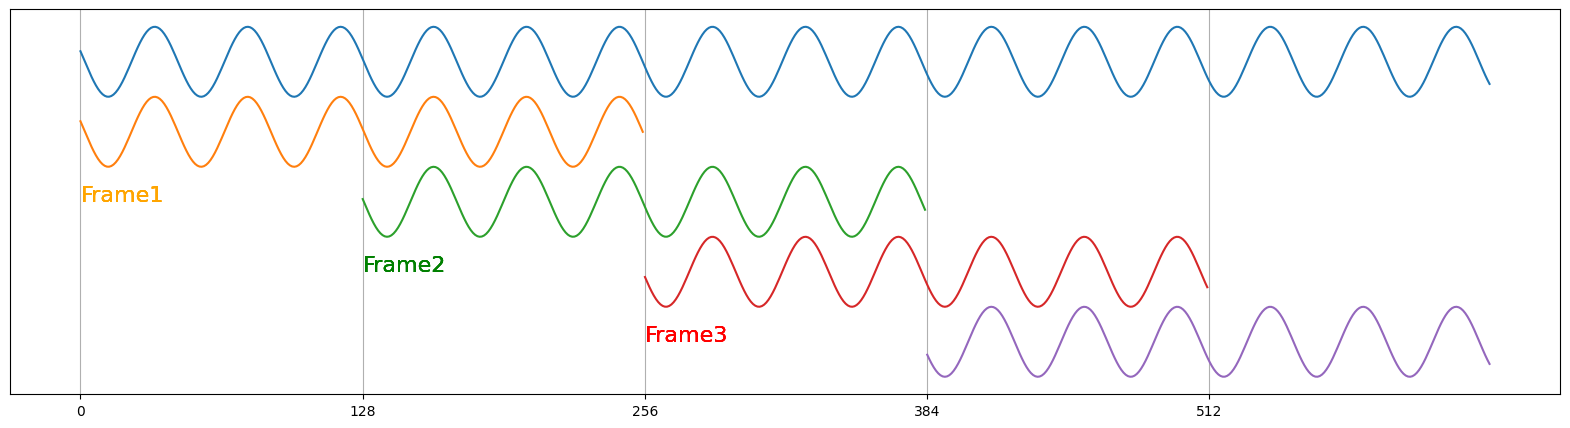

In [ ]:
def plot_short_time(signal, hopSize, winSize, start_frame, dur_frames):
    s  = start_frame
    long_chunk = signal[start_frame * hopSize: (start_frame+ dur_frames) * hopSize]

    plt.figure(figsize=(20,5))
    plt.plot(long_chunk)

    for m in np.arange(0,4):
        start = m * hopSize
        end = m * hopSize + winSize
        frame = long_chunk[start:end]
        plt.plot(np.arange(start, end), frame - (m+1)* 2.0)
        plt.xticks(np.arange(0, len(long_chunk), step=hopSize))
        plt.text(0, -4, 'Frame1', fontsize=16, color='orange')
        plt.text(hopSize, -6, 'Frame2', fontsize=16, color='green')
        plt.text(2*hopSize, -8, 'Frame3', fontsize=16, color='red')


        plt.yticks([])
        plt.grid(True)

# plot a chunk of the synthetic input as well as the audio recording
plot_short_time(melody1, 256, 512, 40, 5)
plot_short_time(melody2, 256, 512, 40, 5)

# change the hop size and window size
plot_short_time(melody1, 128, 256, 40, 5)

Let's look at the zerocrossings for a particular frame and use them to estimate the pitch in Hz for
that frame.

Indices: [ 11  53  95 138 180 222 264 306 348 390 433 475]
Indices diffs: [42 42 43 42 42 42 42 42 42 43 42]
Mean diff: 42.181818
Pitch estimate in Hz: 522.737069


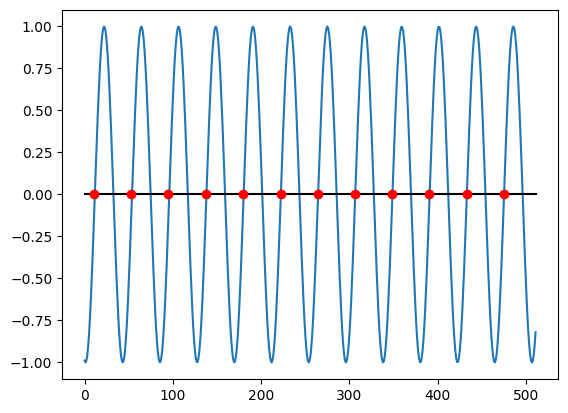

In [ ]:
o = 10 * hopSize
frame = melody1[o:o+winSize]
zero_line = np.zeros(len(frame))

plt.figure()
plt.plot(frame)
plt.plot(zero_line, color='black')

# find locations of zerocrossings
indices = np.nonzero((frame[1:] >= 0) & (frame[:-1] < 0))[0]

# plot them
plt.plot(indices, zero_line[indices], 'o', color='red')
print("Indices: %s" % np.array2string(indices))

# calculate the difference between successive elements
print("Indices diffs: %s" % np.array2string(np.diff(indices)))
# take the mean difference - that's the period in samples
print("Mean diff: %f" % np.mean(np.diff(indices)))
# now compute the pitch estimate
print("Pitch estimate in Hz: %f" % (srate / np.mean(np.diff(indices))))

Now let's look at doing pitch estimation in the frequency domain by
examining the magnitude of the Discrete Fourier Transform (DFT) of the frame.
First we compute the location in frequency bins of the maximum magnitude value
and then convert that value from frequency bin to frequency in Hz.

Frequency bin of magnitude peak: 12.000000
Pitch estimate using DFT: 516.796875


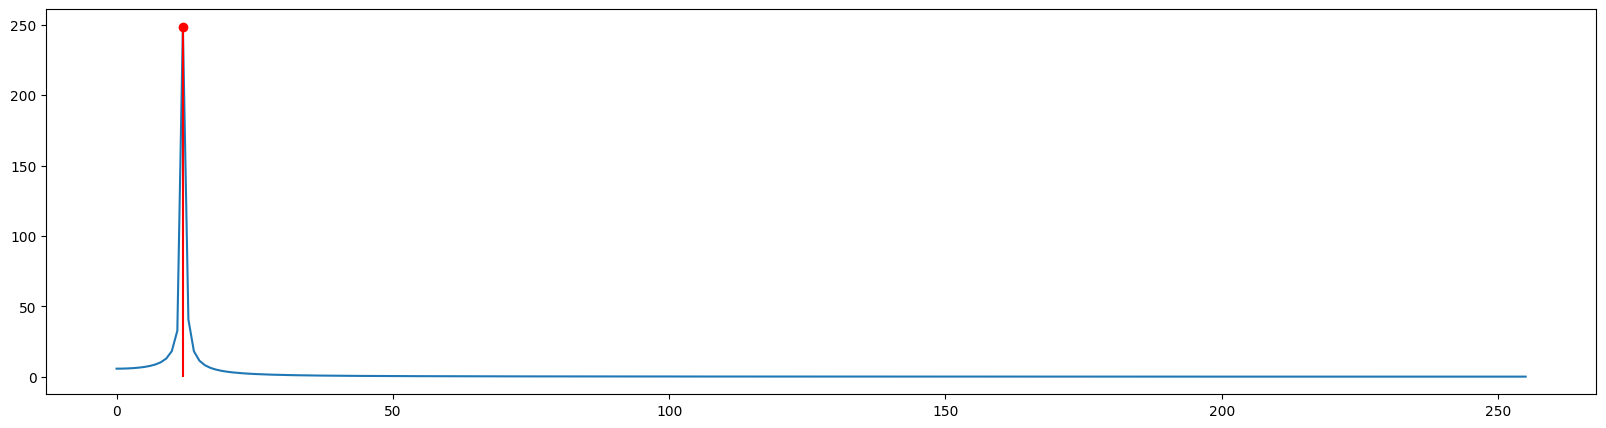

In [ ]:
mag = np.abs(np.fft.fft(frame))
mag = mag[0:int(len(mag)/2)]
plt.figure(figsize=(20,5))
plt.plot(mag)
plt.stem([np.argmax(mag)], [np.max(mag)], linefmt='red')
print("Frequency bin of magnitude peak: %f" % np.argmax(mag))
print("Pitch estimate using DFT: %f" % (np.argmax(mag) * (srate / len(frame))))


Now that we have seen how we can estimate the pitch of a single frame of audio
we can abstract this process into functions and then write a function that
given an audio signal returns the associated pitch track and amplitude track (RMS)
using a particular pitch extraction method.

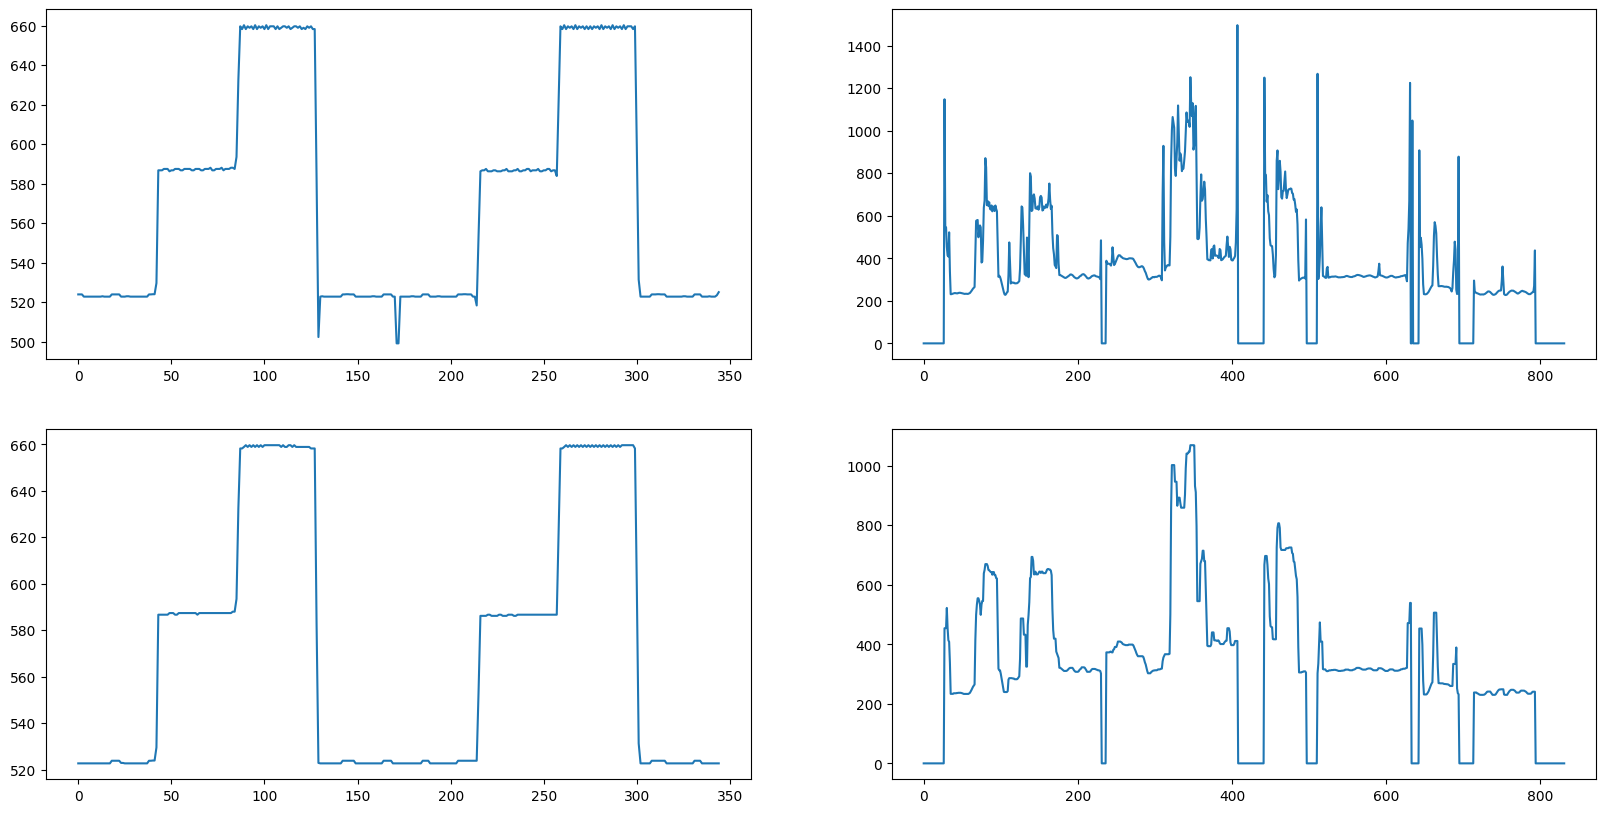

In [ ]:

def pitch_zcrs(frame, srate):
    indices = np.nonzero((frame[1:] >= 0) & (frame[:-1] < 0))[0]
    pitch_estimate = (srate / np.mean(np.diff(indices)))
    return pitch_estimate

def pitch_fft(frame, srate):
    mag = np.abs(np.fft.fft(frame))
    mag = mag[0:int(len(mag)/2)]
    pitch_estimate = np.argmax(mag) * (srate / len(frame))
    return pitch_estimate

def pitch_track(signal, hopSize, winSize, extractor):
    offsets = np.arange(0, len(signal), hopSize)
    pitch_track = np.zeros(len(offsets))
    amp_track = np.zeros(len(offsets))

    for (m,o) in enumerate(offsets):
        frame = signal[o:o+winSize]
        pitch_track[m] = extractor(frame, srate)
        amp_track[m] = np.sqrt(np.mean(np.square(frame)))

        if (pitch_track[m] > 1500):
            pitch_track[m] = 0

    return (amp_track, pitch_track)

# compute the pitch tracks
(at1, pt1) = pitch_track(melody1, 256, 512, pitch_zcrs)
(at2, pt2) = pitch_track(melody2, 256, 512, pitch_zcrs)

# applying median filtering to smooth the pitch tracks
pt3 = signal.medfilt(pt1, kernel_size=7)
pt4 = signal.medfilt(pt2, kernel_size=7)


plt.figure(figsize=(20,10))
plt.subplot(221)
plt.plot(pt1)
plt.subplot(222)
plt.plot(pt2)
plt.subplot(223)
plt.plot(pt3)
plt.subplot(224)
plt.plot(pt4)


The plots provide us some visual indication that our pitch extraction
process is doing something reasonable but it would be nice to be able
to hear the generated pitch track. We can achieve this by using a
sinusoid oscillator that changes instantaneous frequency and amplitude
with every sample. The sonify function takes as input the amplitude
and pitch track and return the resulting audio.

In [ ]:
def sonify(amp_track, pitch_track, srate, hop_size):

    times = np.arange(0.0, float(hop_size * len(pitch_track)) / srate,
                      float(hop_size) / srate)

    # sample locations in time (seconds)
    sample_times = np.linspace(0, np.max(times), int(np.max(times)*srate-1))
    print('times_length', len(times))

    # create linear interpolators for frequencies and amplitudes
    # so that we have a frequency and amplitude value for
    # every sample
    freq_interpolator = interp1d(times,pitch_track)
    amp_interpolator = interp1d(times,amp_track)

    # use the interpolators to calculate per sample frequency and
    # ampitude values
    sample_freqs = freq_interpolator(sample_times)
    sample_amps  = amp_interpolator(sample_times)

    print('sample freqs len', len(sample_freqs))
    # create audio signal
    audio = np.zeros(len(sample_times));
    T = 1.0 / srate
    phase = 0.0

    # update phase according to the sample frequencies
    for i in range(1, len(audio)):
        audio[i] = sample_amps[i] * np.sin(phase)
        phase = phase + (2*np.pi*T*sample_freqs[i])

    return audio

pt1_audio = sonify(at1, pt1, srate, hopSize)
ipd.Audio(pt1_audio,rate=srate)


times_length 345
sample freqs len 88063


In [ ]:
pt2_audio = sonify(at2, pt2, srate, hopSize)
print(hopSize)

ipd.Audio(pt2_audio,rate=srate)


times_length 832
sample freqs len 212735
256


In [ ]:
import numpy as np
from scipy.signal import butter, lfilter
from IPython.display import Audio

def apply_formant(signal, f_center, fs, bandwidth=100):
    """Applies a resonant band-pass filter to simulate a vocal tract resonance."""
    nyquist = 0.5 * fs
    low = (f_center - bandwidth / 2) / nyquist
    high = (f_center + bandwidth / 2) / nyquist
    b, a = butter(2, [low, high], btype='band')
    return lfilter(b, a, signal)

def vocal_sonification_with_amplitude(freq_contour, amp_contour, fs=44100):
    # 1. Generate the source (Sawtooth wave provides rich harmonics for filtering)
    # We use cumulative sum to ensure a smooth frequency sweep without phase jumps
    phase = 2 * np.pi * np.cumsum(freq_contour) / fs
    source = (phase % (2 * np.pi)) / np.pi - 1  # Standard sawtooth wave [-1, 1]

    # 2. Apply "AA" Formants (F1=850, F2=1220, F3=2810 Hz)
    # These frequencies characterize the specific vowel sound
    vocal = apply_formant(source, 850, fs) + \
            apply_formant(source, 1220, fs) + \
            apply_formant(source, 2810, fs)

    # 3. Apply the Amplitude Contour (volume control)
    # This multiplies the signal by the desired volume at every point in time
    sonified_output = vocal * amp_contour

    # Normalize the final output to prevent clipping
    return sonified_output / np.max(np.abs(sonified_output))

# --- Example Usage ---
hop_size = hopSize
print(hopSize )
times = np.arange(0.0, float(hop_size * len(pt2)) / srate,
                      float(hop_size) / srate)

# sample locations in time (seconds)
sample_times = np.linspace(0, np.max(times), int(np.max(times)*srate-1))
print("times length", len(times))
print("pt2 length", len(pt2))

# create linear interpolators for frequencies and amplitudes
# so that we have a frequency and amplitude value for
# every sample
freq_interpolator = interp1d(times,pt2)
amp_interpolator = interp1d(times,at2)

# use the interpolators to calculate per sample frequency and
# ampitude values
sample_freqs = freq_interpolator(sample_times)
sample_amps  = amp_interpolator(sample_times)

print("sample freqs len", len(sample_freqs))
# Frequency Contour: A slight rising pitch (e.g., 200Hz to 300Hz)
#freq_contour = np.linspace(200, 300, len(t))

# Amplitude Contour: Fade in, hold, then fade out
#amp_contour = np.sin(np.pi * t / duration) ** 2  # Smooth bell curve for volume

# Generate and play
vocal_audio = vocal_sonification_with_amplitude(sample_freqs,sample_amps, srate)
Audio(vocal_audio, rate=fs)

256
times length 832
pt2 length 832
sample freqs len 212735


Using the synthesize function we can also plot and hear the pitch track
extracted using the DFT-based method.

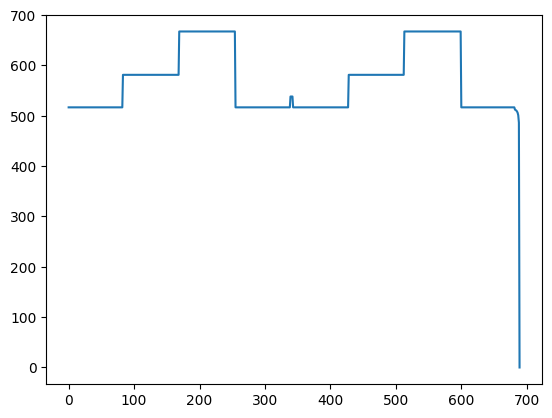

In [ ]:
(at1, pt1) = pitch_track(melody1, 128, 1024, pitch_fft)
plt.figure()
plt.plot(pt1)
plt.show()

In [ ]:
pt1_audio = sonify(at1, pt1, srate, 128)
ipd.Audio(pt1_audio,rate=srate)

times_length 690
sample freqs len 88191


If we decrease the size of the frame used to compute the DFT our frequency resolution
will become more coarse i.e each frequency bins will correspond to a larger number
of Hz. The resulting pitch estimate will not be as accurate and this is something
one can hear for example if we reduce the window size to 256.

In [ ]:
(at1, pt1) = pitch_track(melody1, 128, 256, pitch_fft)
pt1_audio = sonify(at1, pt1, srate, 128)
ipd.Audio(pt1_audio,rate=srate)

times_length 690
sample freqs len 88191


On the other hand if we make the frame much larger then we will start having more than
one note in a frame and that way we will loose some of the rhythm/time information.
Hear what happens when the window size is 16384.

In [ ]:
(at1, pt1) = pitch_track(melody1, 128, 16384, pitch_fft)
pt1_audio = sonify(at1, pt1, srate, 128)
ipd.Audio(pt1_audio,rate=srate)

times_length 690
sample freqs len 88191


The initial choice of a window size of 1024 with a hop size of 128 seems like a good compromise
in terms of time and frequency resolution. Let's hear the result of running the DFT-based pitch
detection on the Amazing Grace recording.

In [ ]:
(at2, pt2) = pitch_track(melody2, 128, 1024, pitch_fft)
pt2_audio = sonify(at2, pt2, srate, 128)
ipd.Audio(pt2_audio,rate=srate)
print(srate)

times_length 1663
sample freqs len 212735
22050


In [ ]:
import numpy as np
import math

def make_sine(freq, duration, samplerate=44100):
    """Generates one cycle of a sine wave."""
    t = np.linspace(0, duration, int(samplerate * duration), endpoint=False)
    return np.sin(2 * np.pi * freq * t)

def addsyn(freq, dur, amplist, samplerate=44100):
    """Creates a waveform by summing sine waves (harmonics)."""
    t = np.linspace(0, dur, int(samplerate * dur), endpoint=False)
    output = np.zeros_like(t)
    for i, amp in enumerate(amplist):
        # Add harmonics (multiples of the base frequency)
        output += amp * make_sine(freq * (i + 1), dur, samplerate)
    # Normalize to prevent clipping
    return t, output / np.max(np.abs(output))

# Example: A simple violin-like sound with overtones
# Amplist: [Fundamental, 2nd Harm, 3rd Harm, ...]
t, violin_wave = addsyn(220, 1, [1, 0.263, 0.14, 0.099, 0.209, 0.02, 0.029, 0.077, 0.017, 0.01])
ipd.Audio(violin_wave, rate=44100)

In [ ]:
import numpy as np
from IPython.display import Audio

def karplus_strong(frequency, duration, sample_rate=44100, decay=0.996):
    """
    Generates a string-like sound at a specific frequency.
    """
    t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)
    # 1. Calculate delay line length (N) based on desired frequency
    N = int(sample_rate / frequency)

    # 2. Initialize the delay line with noise (the "pluck")
    # This represents the initial energy transferred to the string
    ring_buffer = np.random.uniform(-1, 1, N)

    # 3. Generate the output signal
    num_samples = int(duration * sample_rate)
    audio = np.zeros(num_samples)

    for i in range(num_samples):
        # The current sample is the first in the buffer
        audio[i] = ring_buffer[0]

        # 4. Filter: Average the first two samples and apply decay
        # This simulates high-frequency energy loss over time
        new_sample = decay * 0.5 * (ring_buffer[0] + ring_buffer[1])

        # 5. Update the buffer (remove first, append new)
        ring_buffer = np.roll(ring_buffer, -1)
        ring_buffer[-1] = new_sample

    return t, audio

# --- Usage in Notebook ---
fs = 44100
# Play an A4 note (440 Hz) for 2 seconds
t, note_a4 = karplus_strong(440, 2, sample_rate=fs)

# Use IPython to display the player widget
Audio(note_a4, rate=fs)


In [ ]:
# --- 12-Tone Equal Temperament (12-TET) ---
# Third is 4 semitones away: f * 2^(4/12)
f_root = 220
f_3rd_tet = f_root * (2**(4/12))
t, audio_root = karplus_strong(f_root, 4, sample_rate=fs)
t, audio_3rd_tet = karplus_strong(f_3rd_tet, 4, sample_rate=fs)
chord_tet = audio_root + audio_3rd_tet
ipd.Audio(chord_tet, rate=fs)





In [ ]:
# --- Just Intonation ---
# Pure major third ratio is 5/4
f_3rd_just = f_root * (5/4)
t, audio_just = karplus_strong(f_3rd_just, 4, sample_rate=fs)
chord_just = audio_root + audio_just
ipd.Audio(chord_just, rate=fs)


In [ ]:
# --- 12-Tone Equal Temperament (12-TET) ---
# Third is 4 semitones away: f * 2^(4/12)
f_root = 220
f_3rd_tet = f_root * (2**(4/12))
t, audio_root = addsyn(f_root, 3, [1, 0.263, 0.14])
t, audio_3rd_tet = addsyn(f_3rd_tet, 3, [1, 0.263, 0.14])
chord_tet = audio_root + audio_3rd_tet
ipd.Audio(chord_tet, rate=fs)



In [ ]:
# --- 12-Tone Equal Temperament (12-TET) ---
# Third is 4 semitones away: f * 2^(4/12)
f_root = 220
f_3rd_just = f_root * (5/4)

t, audio_root = addsyn(f_root, 3, [1, 0.263, 0.14])
t, audio_3rd_just = addsyn(f_3rd_just, 3, [1, 0.263, 0.14])
chord_just = audio_root + audio_3rd_just
ipd.Audio(chord_just, rate=fs)

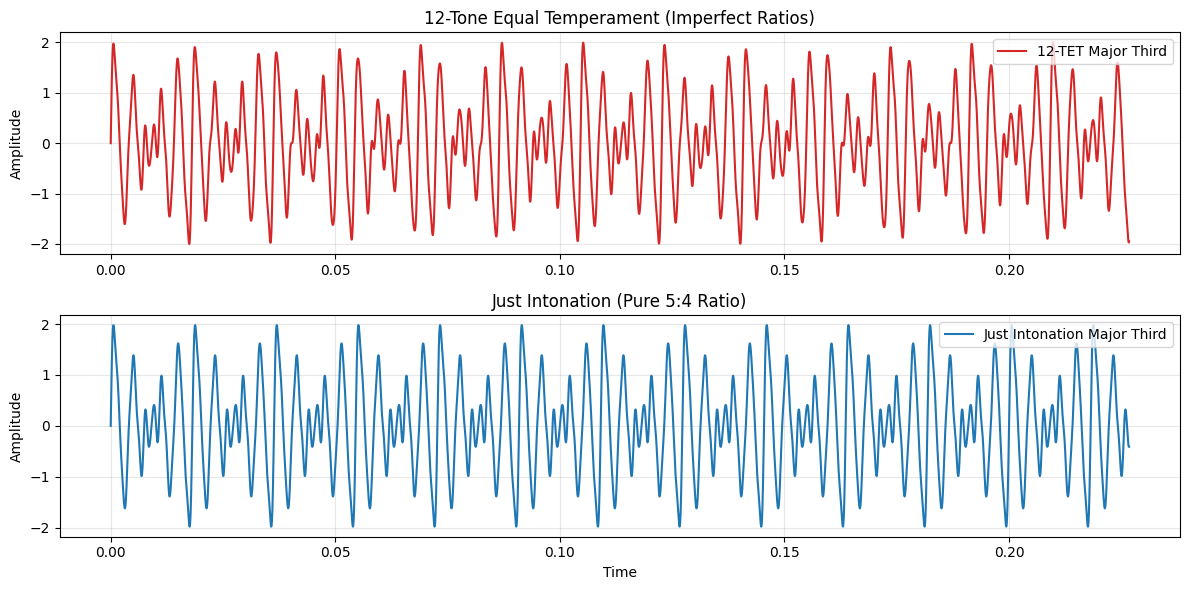

In [ ]:
# Plotting
plt.figure(figsize=(12, 6))
nsamples = 10000
tplot = t[0:nsamples]
plot_tet = chord_tet[0:nsamples]
plot_just = chord_just[0:nsamples]

# Subplot 1: 12-TET (Note the shifting pattern/interference)
plt.subplot(2, 1, 1)
plt.plot(tplot, plot_tet, color='tab:red', label='12-TET Major Third')
plt.title("12-Tone Equal Temperament (Imperfect Ratios)")
plt.ylabel("Amplitude")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Subplot 2: Just Intonation (Note the clean, repeating periodic pattern)
plt.subplot(2, 1, 2)
plt.plot(tplot, plot_just, color='tab:blue', label='Just Intonation Major Third')
plt.title("Just Intonation (Pure 5:4 Ratio)")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


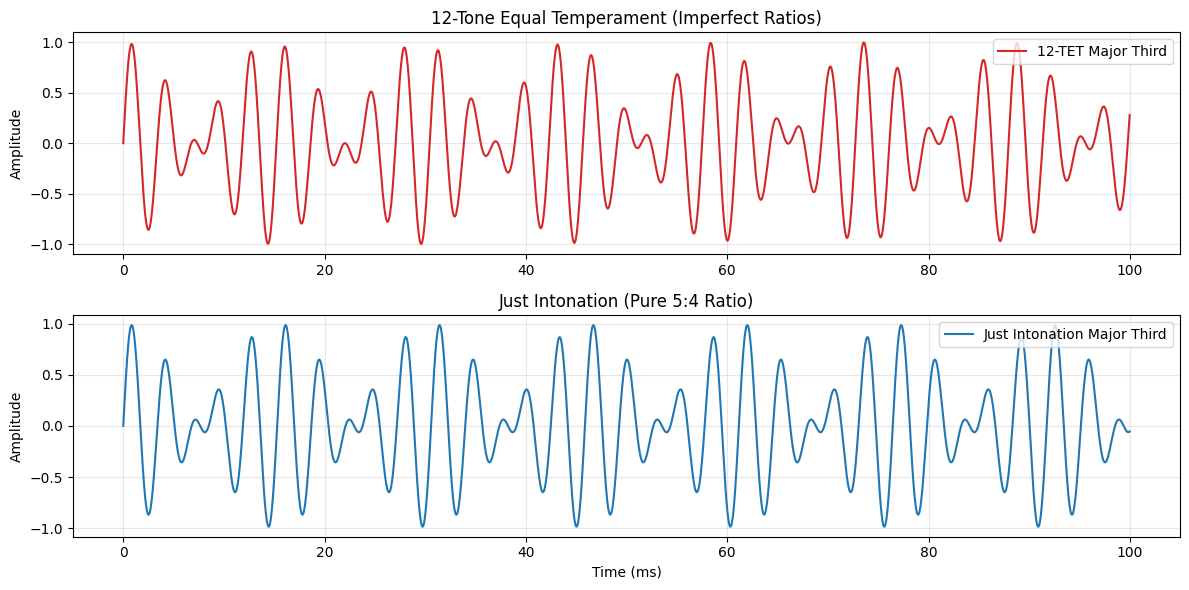

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def get_chord_wave(freqs, duration=0.1, fs=44100):
    """Generates a combined waveform for a list of frequencies."""
    t = np.linspace(0, duration, int(fs * duration), endpoint=False)
    # Sum individual sine waves and normalize
    wave = sum(np.sin(2 * np.pi * f * t) for f in freqs)
    return t, wave / len(freqs)

# Frequencies for a Major Third (C4 to E4)
f_root = 261.63
f_3rd_tet = f_root * (2**(4/12))  # 12-TET: 4 semitones
f_3rd_just = f_root * (5/4)       # Just Intonation: 5:4 ratio

# Generate waves
t_tet, wave_tet = get_chord_wave([f_root, f_3rd_tet])
t_just, wave_just = get_chord_wave([f_root, f_3rd_just])

# Plotting
plt.figure(figsize=(12, 6))

# Subplot 1: 12-TET (Note the shifting pattern/interference)
plt.subplot(2, 1, 1)
plt.plot(t_tet * 1000, wave_tet, color='tab:red', label='12-TET Major Third')
plt.title("12-Tone Equal Temperament (Imperfect Ratios)")
plt.ylabel("Amplitude")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Subplot 2: Just Intonation (Note the clean, repeating periodic pattern)
plt.subplot(2, 1, 2)
plt.plot(t_just * 1000, wave_just, color='tab:blue', label='Just Intonation Major Third')
plt.title("Just Intonation (Pure 5:4 Ratio)")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
from IPython.display import Audio

def apply_formant(signal, f_center, fs, bandwidth=100):
    """Applies a resonant band-pass filter to simulate a vocal tract resonance."""
    nyquist = 0.5 * fs
    low = (f_center - bandwidth / 2) / nyquist
    high = (f_center + bandwidth / 2) / nyquist
    b, a = butter(2, [low, high], btype='band')
    return lfilter(b, a, signal)

def vocal_sonification(freq_contour, fs=44100):
    # 1. Generate the source (Sawtooth wave provides rich harmonics)
    t = np.linspace(0, len(freq_contour)/fs, len(freq_contour), endpoint=False)
    phase = 2 * np.pi * np.cumsum(freq_contour) / fs
    source = (phase % (2 * np.pi)) / np.pi - 1  # Standard sawtooth

    # 2. Apply "AA" Formants (F1=850, F2=1220, F3=2810)
    vocal = apply_formant(source, 850, fs) + \
            apply_formant(source, 1220, fs) + \
            apply_formant(source, 2810, fs)

    return vocal / np.max(np.abs(vocal)) # Normalize
